In [ ]:
# GPU kontrolü
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.cuda.is_available()}")

GPU: Tesla T4
CUDA: True


In [ ]:
!pip install timm albumentations opencv-python-headless -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, recall_score, precision_score)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")

Cihaz: cuda


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/SkinXAI"
os.makedirs(f"{BASE}/models_v3", exist_ok=True)
print("Drive bağlı ✅")

Mounted at /content/drive
Drive bağlı ✅


## 1. Veri Yükleme ve Dengeleme

Asıl sorun: nevus %56.8. Çözüm: **capped oversampling** — büyük sınıfları kırp, küçük sınıfları augmentation ile çoğalt.

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split


BASE = "/content/drive/MyDrive/SkinXAI"


df = pd.read_csv(f"{BASE}/HAM10000_metadata.csv")


label_map = {
    "akiec": "ak",
    "bcc": "bcc",
    "bkl": "bkl",
    "df": "df",
    "mel": "melanoma",
    "nv": "nevus",
    "vasc": "vasc"
}


df["label"] = df["dx"].map(label_map)


CLASS_NAMES = [
    "ak",
    "bcc",
    "bkl",
    "df",
    "melanoma",
    "nevus",
    "vasc"
]


df = df[df["label"].isin(CLASS_NAMES)]

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

train_df.to_csv(f"{BASE}/train_df.csv", index=False)
val_df.to_csv(f"{BASE}/val_df.csv", index=False)
test_df.to_csv(f"{BASE}/test_df.csv", index=False)


label_to_idx = {n: i for i, n in enumerate(CLASS_NAMES)}
idx_to_label = {i: n for n, i in label_to_idx.items()}


for df_part in [train_df, val_df, test_df]:
    df_part["label_idx"] = df_part["label"].map(label_to_idx)


print("=== Train Dağılımı ===")
print(train_df["label"].value_counts())

print("\n=== Validation Dağılımı ===")
print(val_df["label"].value_counts())

print("\n=== Test Dağılımı ===")
print(test_df["label"].value_counts())

print("\nCSV dosyaları oluşturuldu ✅")
import os

imageid_path = {}


for fname in os.listdir(f"{BASE}/HAM10000_images_part_1"):
    image_id = fname.split(".")[0]
    imageid_path[image_id] = os.path.join(
        f"{BASE}/HAM10000_images_part_1",
        fname
    )


for fname in os.listdir(f"{BASE}/HAM10000_images_part_2"):
    image_id = fname.split(".")[0]
    imageid_path[image_id] = os.path.join(
        f"{BASE}/HAM10000_images_part_2",
        fname
    )


train_df["image_path"] = train_df["image_id"].map(imageid_path)

val_df["image_path"] = val_df["image_id"].map(imageid_path)

test_df["image_path"] = test_df["image_id"].map(imageid_path)

print("image_path kolonları oluşturuldu ✅")

=== Train Dağılımı ===
label
nevus       4693
melanoma     779
bkl          769
bcc          360
ak           229
vasc          99
df            81
Name: count, dtype: int64

=== Validation Dağılımı ===
label
nevus       1006
melanoma     167
bkl          165
bcc           77
ak            49
vasc          21
df            17
Name: count, dtype: int64

=== Test Dağılımı ===
label
nevus       1006
melanoma     167
bkl          165
bcc           77
ak            49
vasc          22
df            17
Name: count, dtype: int64

CSV dosyaları oluşturuldu ✅
image_path kolonları oluşturuldu ✅


In [ ]:

TARGET_PER_CLASS = {
    "ak":       1500,
    "bcc":      2500,
    "bkl":      2500,
    "df":       1500,
    "melanoma": 2500,
    "nevus":    2500,

    "vasc":     1500,
}

balanced_parts = []
rng = np.random.default_rng(42)

for cls, target in TARGET_PER_CLASS.items():
    cls_df = train_df[train_df["label"] == cls].copy()
    n = len(cls_df)
    if n >= target:

        sampled = cls_df.sample(n=target, random_state=42)
    else:

        repeats = (target // n) + 1
        sampled = pd.concat([cls_df] * repeats, ignore_index=True)
        sampled = sampled.sample(n=target, random_state=42)
    balanced_parts.append(sampled)

balanced_train_df = pd.concat(balanced_parts, ignore_index=True).sample(frac=1, random_state=42)
balanced_train_df = balanced_train_df.reset_index(drop=True)

print("=== Dengeli Train Dağılımı ===")
print(balanced_train_df["label"].value_counts())
print(f"Toplam: {len(balanced_train_df)}")
print(f"Toplam: {len(balanced_train_df)}")

=== Dengeli Train Dağılımı ===
label
nevus       2500
melanoma    2500
bcc         2500
bkl         2500
ak          1500
df          1500
vasc        1500
Name: count, dtype: int64
Toplam: 14500
Toplam: 14500


## 2. Dataset & Augmentation

Minority sınıflar için ekstra agresif augmentation — oversampled örnekler her seferinde farklı görünür.

In [ ]:
class SkinDataset(Dataset):
    """
    Küçük sınıflara daha güçlü augmentation uygulanır.
    """

    MINORITY = {"ak", "df", "vasc"}
    MEDIUM   = {"melanoma", "bcc", "bkl"}

    def __init__(self, df, is_train=True, img_size=224):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def _get_transform(self, label_name):

        s = self.img_size

        norm = A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )


        if not self.is_train:
            return A.Compose([
                A.Resize(s, s),
                norm,
                ToTensorV2()
            ])


        if label_name in self.MINORITY:

            return A.Compose([

                A.Resize(s, s),

                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),

                A.Rotate(limit=180, p=0.8),

                A.RandomBrightnessContrast(
                    brightness_limit=0.3,
                    contrast_limit=0.3,
                    p=0.7
                ),

                A.HueSaturationValue(
                    hue_shift_limit=20,
                    sat_shift_limit=40,
                    val_shift_limit=20,
                    p=0.6
                ),

                A.OneOf([
                    A.GridDistortion(p=1.0),
                    A.ElasticTransform(p=1.0),
                    A.OpticalDistortion(p=1.0),
                ], p=0.5),

                A.CoarseDropout(
                    max_holes=8,
                    max_height=s // 8,
                    max_width=s // 8,
                    p=0.4
                ),

                norm,
                ToTensorV2()
            ])


        elif label_name in self.MEDIUM:

            return A.Compose([

                A.Resize(s, s),

                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),

                A.Rotate(limit=90, p=0.5),

                A.RandomBrightnessContrast(p=0.5),

                A.HueSaturationValue(p=0.4),

                norm,
                ToTensorV2()
            ])


        else:

            return A.Compose([

                A.Resize(s, s),

                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),

                A.Rotate(limit=30, p=0.5),

                A.RandomBrightnessContrast(
                    brightness_limit=0.2,
                    contrast_limit=0.2,
                    p=0.4
                ),

                A.HueSaturationValue(
                    hue_shift_limit=10,
                    sat_shift_limit=20,
                    val_shift_limit=10,
                    p=0.3
                ),

                norm,
                ToTensorV2()
            ])

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        path = row["image_path"]

        label = row["label_idx"]

        label_name = row["label"]

        img = cv2.imread(path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        tfm = self._get_transform(label_name)

        img = tfm(image=img)["image"]

        return img, label



train_dataset = SkinDataset(
    balanced_train_df,
    is_train=True,
    img_size=224
)

val_dataset = SkinDataset(
    val_df,
    is_train=False,
    img_size=224
)

test_dataset = SkinDataset(
    test_df,
    is_train=False,
    img_size=224
)



labels_arr = balanced_train_df["label_idx"].values

class_counts = np.bincount(labels_arr, minlength=7)

class_weights_sampler = 1.0 / class_counts

sample_weights = class_weights_sampler[labels_arr]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)



BATCH = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)



img, lbl = next(iter(train_loader))

print(f"Batch shape: {img.shape}")

print(
    f"Train: {len(train_dataset)} | "
    f"Val: {len(val_dataset)} | "
    f"Test: {len(test_dataset)}"
)

print("DataLoader hazır ✅")

Batch shape: torch.Size([32, 3, 224, 224])
Train: 14500 | Val: 1502 | Test: 1503
DataLoader hazır ✅


## 3. Model — EfficientNetV2-S

B4'e göre ~%2-3 daha iyi ImageNet accuracy, daha hızlı eğitim.

In [ ]:
class SkinModel(nn.Module):

    def __init__(self, num_classes=7, dropout=0.3):

        super().__init__()

        self.backbone = timm.create_model(
            "tf_efficientnetv2_s",
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes)
        )

    def forward(self, x):

        x = self.backbone(x)

        return self.head(x)


model = SkinModel(num_classes=7).to(device)

total = sum(p.numel() for p in model.parameters())

print("Model: EfficientNetV2-S")

print(f"Parametre: {total:,}")

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Model: EfficientNetV2-S
Parametre: 20,186,455


## 4. Loss & MixUp

Label Smoothing → overfit'i azaltır. MixUp → sınıf sınırlarını yumuşatır, minority class geçişlerini öğretir.

In [ ]:


class LabelSmoothingLoss(nn.Module):

    def __init__(self, classes=7, smoothing=0.1, weight=None):

        super().__init__()

        self.smoothing = smoothing
        self.cls = classes
        self.weight = weight

    def forward(self, pred, target):

        confidence = 1.0 - self.smoothing

        smooth_val = self.smoothing / (self.cls - 1)

        one_hot = torch.zeros_like(pred).scatter_(
            1,
            target.unsqueeze(1),
            1
        )

        smooth_one_hot = (
            one_hot * confidence
            + (1 - one_hot) * smooth_val
        )

        log_prob = F.log_softmax(pred, dim=1)

        if self.weight is not None:

            w = self.weight[target].unsqueeze(1)

            loss = -(
                smooth_one_hot * log_prob * w
            ).sum(dim=1).mean()

        else:

            loss = -(
                smooth_one_hot * log_prob
            ).sum(dim=1).mean()

        return loss




def mixup_data(x, y, alpha=0.2):

    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)

    idx = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[idx]

    y_a, y_b = y, y[idx]

    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):

    return (
        lam * criterion(pred, y_a)
        + (1 - lam) * criterion(pred, y_b)
    )



weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(7),
    y=balanced_train_df["label_idx"].values
)

weights_t = torch.FloatTensor(weights_np).to(device)

print("Class weights:")

for n, w in zip(CLASS_NAMES, weights_np):
    print(f"  {n:10s}: {w:.2f}")


criterion = LabelSmoothingLoss(
    classes=7,
    smoothing=0.1,
    weight=weights_t
)

Class weights:
  ak        : 1.38
  bcc       : 0.83
  bkl       : 0.83
  df        : 1.38
  melanoma  : 0.83
  nevus     : 0.83
  vasc      : 1.38


## 5. Eğitim Döngüsü

In [ ]:
from sklearn.metrics import f1_score, recall_score



def train_epoch(model, loader, optimizer, criterion, device, use_mixup=True):

    model.train()

    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):

        images = images.to(device)

        labels = labels.to(device)

        # ----------------------------------------------------
        # MIXUP
        # ----------------------------------------------------

        if use_mixup and np.random.random() < 0.4:

            images, y_a, y_b, lam = mixup_data(
                images,
                labels,
                alpha=0.2
            )

            optimizer.zero_grad()

            outputs = model(images)

            loss = mixup_criterion(
                criterion,
                outputs,
                y_a,
                y_b,
                lam
            )

        else:

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)



        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()


        total_loss += loss.item()

        correct += (
            outputs.argmax(1) == labels
        ).sum().item()

        total += labels.size(0)

        if batch_idx % 100 == 0:

            print(
                f"  Batch {batch_idx}/{len(loader)} "
                f"| Loss: {loss.item():.3f}"
            )

    epoch_loss = total_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc



def eval_epoch(model, loader, device):

    model.eval()

    all_preds = []

    all_labels = []

    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = probs.argmax(1)

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    all_preds = np.array(all_preds)

    all_labels = np.array(all_labels)

    all_probs = np.array(all_probs)


    acc = (all_preds == all_labels).mean()

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    per_class_recall = recall_score(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    return (
        acc,
        macro_f1,
        per_class_recall,
        all_preds,
        all_labels,
        all_probs
    )


print("Fonksiyonlar hazır ✅")

Fonksiyonlar hazır ✅


## 6. Aşama 1 — Backbone Dondur, Head Eğit (5 epoch)

In [ ]:



for p in model.backbone.parameters():
    p.requires_grad = False


optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

print("AŞAMA 1: Backbone donduruldu, head eğitiliyor...")
print("=" * 50)


for epoch in range(1, 6):

    print(f"\nEpoch {epoch}/5")



    tr_loss, tr_acc = train_epoch(
        model,
        train_loader,
        optimizer_p1,
        criterion,
        device,
        use_mixup=False
    )


    val_acc, val_f1, per_cls, _, _, _ = eval_epoch(
        model,
        val_loader,
        device
    )



    print(
        f"Train Loss: {tr_loss:.3f} | "
        f"Train Acc: {tr_acc:.3f}"
    )

    print(
        f"Val Acc: {val_acc:.3f} | "
        f"Val Macro-F1: {val_f1:.3f}"
    )

    per_cls_str = " | ".join([
        f"{CLASS_NAMES[i]}:{per_cls[i]:.2f}"
        for i in range(7)
    ])

    print(f"Per-class Recall: {per_cls_str}")


print("\nAşama 1 tamamlandı ✅")
print("Aşama 1 tamamlandı ✅")

AŞAMA 1: Backbone donduruldu, head eğitiliyor...

Epoch 1/5
  Batch 0/454 | Loss: 2.409
  Batch 100/454 | Loss: 1.405
  Batch 200/454 | Loss: 1.248
  Batch 300/454 | Loss: 1.346
  Batch 400/454 | Loss: 1.469
Train Loss: 1.340 | Train Acc: 0.608
Val Acc: 0.665 | Val Macro-F1: 0.543
Per-class Recall: ak:0.37 | bcc:0.69 | bkl:0.68 | df:0.53 | melanoma:0.60 | nevus:0.69 | vasc:0.62

Epoch 2/5
  Batch 0/454 | Loss: 1.146
  Batch 100/454 | Loss: 1.144
  Batch 200/454 | Loss: 1.140
  Batch 300/454 | Loss: 1.079
  Batch 400/454 | Loss: 1.287
Train Loss: 1.256 | Train Acc: 0.657
Val Acc: 0.724 | Val Macro-F1: 0.546
Per-class Recall: ak:0.33 | bcc:0.79 | bkl:0.73 | df:0.35 | melanoma:0.51 | nevus:0.78 | vasc:0.57

Epoch 3/5
  Batch 0/454 | Loss: 1.176
  Batch 100/454 | Loss: 1.407
  Batch 200/454 | Loss: 1.336
  Batch 300/454 | Loss: 1.081
  Batch 400/454 | Loss: 1.184
Train Loss: 1.240 | Train Acc: 0.666
Val Acc: 0.691 | Val Macro-F1: 0.567
Per-class Recall: ak:0.39 | bcc:0.66 | bkl:0.76 | df:0

In [ ]:
import os
import torch


save_dir = "/content/drive/MyDrive/SkinXAI/models_v3"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "skinxai_v3_best.pth")


if os.path.exists(save_path):
    checkpoint_old = torch.load(save_path, map_location="cpu", weights_only=False)
    best_f1 = checkpoint_old.get('val_f1', 0)
else:
    best_f1 = 0

if val_f1 > best_f1:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'val_f1': val_f1,
        'val_acc': val_acc
    }
    torch.save(checkpoint, save_path)
    print(f"Epoch: {epoch} | Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f} | Durum: Kaydedildi")
else:
    print(f"Epoch: {epoch} | Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f} | Durum: Korunan (En İyi: {best_f1:.4f})")

Epoch: 5 | Val F1: 0.5447 | Val Acc: 0.7037 | Durum: Kaydedildi


In [ ]:
import os, torch

path = "/content/drive/MyDrive/SkinXAI/models_v3/skinxai_v3_best.pth"


ckpt = torch.load(path, map_location="cpu", weights_only=False)
print(f"✅ Checkpoint var!")
print(f"   Epoch: {ckpt.get('epoch')}")
print(f"   Val F1: {ckpt.get('val_f1'):.4f}")
print(f"   Val Acc: {ckpt.get('val_acc'):.4f}")

✅ Checkpoint var!
   Epoch: 5
   Val F1: 0.5447
   Val Acc: 0.7037


## 7. Aşama 2 — Fine-tune (25 epoch)

Differential learning rate: backbone için düşük, head için yüksek. Macro-F1 üzerinden early stopping.

In [ ]:

for p in model.parameters():
    p.requires_grad = True


# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer_p2 = torch.optim.AdamW(

    [
        {
            "params": model.backbone.parameters(),
            "lr": 5e-6
        },

        {
            "params": model.head.parameters(),
            "lr": 5e-5
        },
    ],

    weight_decay=1e-4
)




scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2,
    T_0=10,
    T_mult=1,
    eta_min=1e-7
)




N_EPOCHS = 25

PATIENCE = 6

best_f1 = 0.0

patience_c = 0


history = {
    "train_loss": [],
    "val_acc": [],
    "val_f1": [],
    "per_class_recall": []
}


SAVE_PATH = f"{BASE}/models_v3/skinxai_v3_best.pth"


print("AŞAMA 2: Fine-tuning başlıyor...")

print("=" * 60)

print(f"Kayıt yolu: {SAVE_PATH}")




for epoch in range(1, N_EPOCHS + 1):

    print(f"\nEpoch {epoch}/{N_EPOCHS}")



    tr_loss, tr_acc = train_epoch(
        model,
        train_loader,
        optimizer_p2,
        criterion,
        device,
        use_mixup=True
    )


    val_acc, val_f1, per_cls, _, _, _ = eval_epoch(
        model,
        val_loader,
        device
    )

    scheduler.step()



    history["train_loss"].append(tr_loss)

    history["val_acc"].append(val_acc)

    history["val_f1"].append(val_f1)

    history["per_class_recall"].append(
        per_cls.tolist()
    )


    print(
        f"Train Loss: {tr_loss:.3f} | "
        f"Train Acc: {tr_acc:.3f}"
    )

    print(
        f"Val Acc: {val_acc:.3f} | "
        f"Val Macro-F1: {val_f1:.3f}"
    )

    print("\nPer-class Recall:")

    for i, name in enumerate(CLASS_NAMES):

        bar = "█" * int(per_cls[i] * 20)

        print(
            f"  {name:10s}: "
            f"{per_cls[i]:.3f}  {bar}"
        )


    if val_f1 > best_f1:

        best_f1 = val_f1

        patience_c = 0

        torch.save(

            {
                "epoch": epoch,

                "model_state_dict": model.state_dict(),

                "val_acc": val_acc,

                "val_f1": val_f1,

                "per_class_recall": per_cls.tolist(),

                "class_names": CLASS_NAMES,
            },

            SAVE_PATH
        )

        print(
            f"\n✅ Best model kaydedildi! "
            f"Macro-F1: {best_f1:.4f}"
        )

    else:

        patience_c += 1

        print(
            f"\n⏳ Patience: "
            f"{patience_c}/{PATIENCE}"
        )


        if patience_c >= PATIENCE:

            print(
                f"\n🛑 Early stopping "
                f"({epoch}. epoch)"
            )

            break


print(
    f"\nEğitim tamamlandı ✅\n"
    f"Best Val Macro-F1: {best_f1:.4f}"
)



AŞAMA 2: Fine-tuning başlıyor...
Kayıt yolu: /content/drive/MyDrive/SkinXAI/models_v3/skinxai_v3_best.pth

Epoch 1/25
  Batch 0/454 | Loss: 1.151
  Batch 100/454 | Loss: 0.970
  Batch 200/454 | Loss: 0.882
  Batch 300/454 | Loss: 1.225
  Batch 400/454 | Loss: 1.165
Train Loss: 1.257 | Train Acc: 0.584
Val Acc: 0.756 | Val Macro-F1: 0.617

Per-class Recall:
  ak        : 0.367  ███████
  bcc       : 0.857  █████████████████
  bkl       : 0.624  ████████████
  df        : 0.647  ████████████
  melanoma  : 0.629  ████████████
  nevus     : 0.811  ████████████████
  vasc      : 0.810  ████████████████

✅ Best model kaydedildi! Macro-F1: 0.6174

Epoch 2/25
  Batch 0/454 | Loss: 1.353
  Batch 100/454 | Loss: 1.329
  Batch 200/454 | Loss: 1.245
  Batch 300/454 | Loss: 0.936
  Batch 400/454 | Loss: 1.177
Train Loss: 1.187 | Train Acc: 0.614
Val Acc: 0.770 | Val Macro-F1: 0.633

Per-class Recall:
  ak        : 0.469  █████████
  bcc       : 0.870  █████████████████
  bkl       : 0.691  ████████

## 8. Eğitim Grafiği

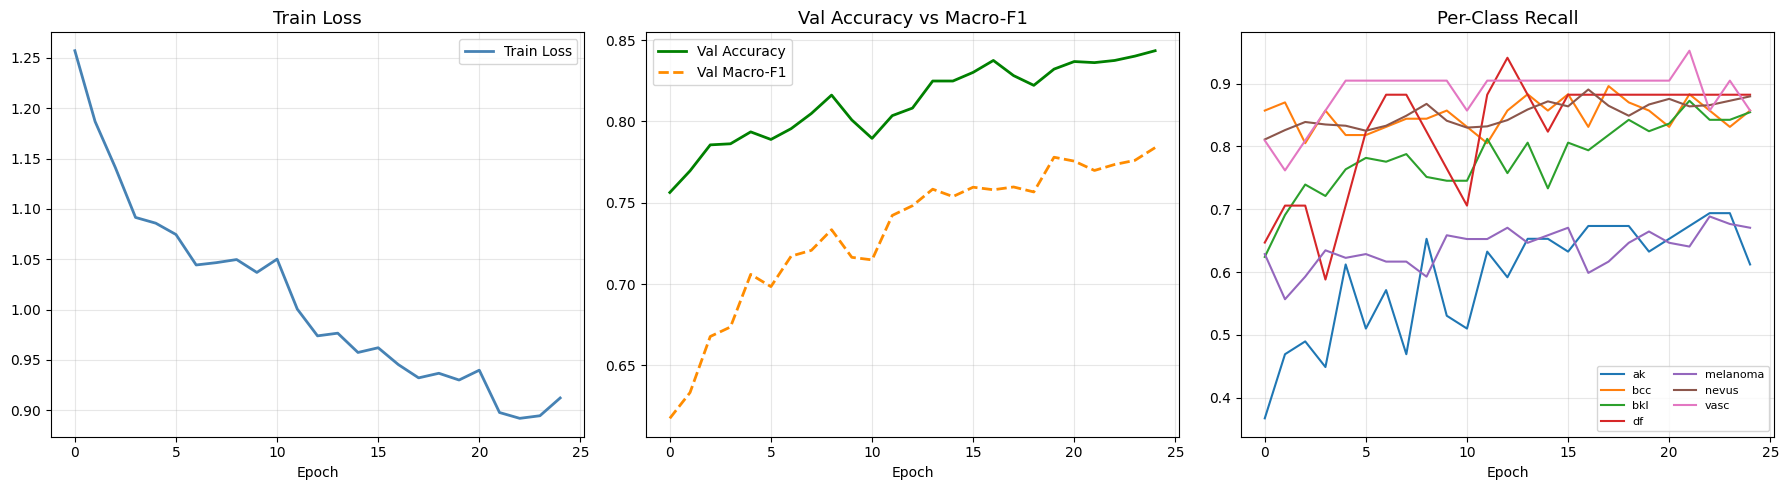

Grafik kaydedildi ✅


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue", lw=2)
axes[0].set_title("Train Loss", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3); axes[0].legend()


axes[1].plot(history["val_acc"], label="Val Accuracy", color="green", lw=2)
axes[1].plot(history["val_f1"],  label="Val Macro-F1", color="darkorange", lw=2, ls="--")
axes[1].set_title("Val Accuracy vs Macro-F1", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3); axes[1].legend()


pcr = np.array(history["per_class_recall"])
for i, name in enumerate(CLASS_NAMES):
    axes[2].plot(pcr[:, i], label=name, lw=1.5)
axes[2].set_title("Per-Class Recall", fontsize=13)
axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(f"{BASE}/models_v3/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi ✅")

## 9. Per-Class Threshold Optimizasyonu

Her sınıf için validation seti üzerinde en iyi threshold'u bul. Bu sayede küçük sınıflar biraz daha "şans" kazanır.

In [ ]:

ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Model yüklendi — Val Acc: {ckpt['val_acc']:.4f} | Macro-F1: {ckpt['val_f1']:.4f}")


_, _, _, val_preds, val_labels, val_probs = eval_epoch(model, val_loader, device)
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)


THRESHOLD_RANGE = np.arange(0.10, 0.60, 0.02)

print("Per-Class Threshold Aranıyor...")
best_thresholds = {}

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_mask = (val_labels == cls_idx)
    best_thr = 0.5
    best_rec = 0.0
    best_f1_cls = 0.0

    for thr in THRESHOLD_RANGE:

        preds_mod = val_probs.argmax(axis=1).copy()

        preds_mod[val_probs[:, cls_idx] > thr] = cls_idx

        rec = recall_score(val_labels, preds_mod,
                           labels=[cls_idx], average="macro", zero_division=0)
        f1_cls = f1_score(val_labels, preds_mod,
                          labels=[cls_idx], average="macro", zero_division=0)

        if rec >= 0.50 and f1_cls > best_f1_cls:
            best_f1_cls = f1_cls
            best_thr = thr
            best_rec = rec

    best_thresholds[cls_idx] = best_thr
    print(f"  {cls_name:10s}: threshold={best_thr:.2f}  recall={best_rec:.3f}  f1={best_f1_cls:.3f}")

print("Threshold'lar belirlendi ✅")

Model yüklendi — Val Acc: 0.8435 | Macro-F1: 0.7839
Per-Class Threshold Aranıyor...
  ak        : threshold=0.26  recall=0.694  f1=0.747
  bcc       : threshold=0.36  recall=0.870  f1=0.802
  bkl       : threshold=0.40  recall=0.861  f1=0.728
  df        : threshold=0.34  recall=0.882  f1=0.833
  melanoma  : threshold=0.48  recall=0.671  f1=0.622
  nevus     : threshold=0.22  recall=0.937  f1=0.927
  vasc      : threshold=0.30  recall=0.905  f1=0.905
Threshold'lar belirlendi ✅


## 10. Test Seti Final Değerlendirmesi

In [ ]:

_, _, _, test_preds_base, test_labels, test_probs = eval_epoch(model, test_loader, device)
test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)


test_preds_thr = test_probs.argmax(axis=1).copy()
for cls_idx, thr in best_thresholds.items():
    test_preds_thr[test_probs[:, cls_idx] > thr] = cls_idx

print("=" * 60)
print("BASELINE (argmax)")
print("=" * 60)
base_acc = (test_preds_base == test_labels).mean()
base_f1  = f1_score(test_labels, test_preds_base, average="macro", zero_division=0)
print(f"Overall Accuracy: {base_acc:.4f}")
print(f"Macro F1:         {base_f1:.4f}")
print()
print(classification_report(test_labels, test_preds_base,
                             target_names=CLASS_NAMES, zero_division=0))

print("=" * 60)
print("THRESHOLD UYGULANMIŞ")
print("=" * 60)
thr_acc = (test_preds_thr == test_labels).mean()
thr_f1  = f1_score(test_labels, test_preds_thr, average="macro", zero_division=0)
print(f"Overall Accuracy: {thr_acc:.4f}")
print(f"Macro F1:         {thr_f1:.4f}")
print()
print(classification_report(test_labels, test_preds_thr,
                             target_names=CLASS_NAMES, zero_division=0))

BASELINE (argmax)
Overall Accuracy: 0.8317
Macro F1:         0.7342

              precision    recall  f1-score   support

          ak       0.91      0.43      0.58        49
         bcc       0.71      0.92      0.80        77
         bkl       0.62      0.79      0.69       165
          df       0.89      0.47      0.62        17
    melanoma       0.55      0.70      0.62       167
       nevus       0.96      0.88      0.91      1006
        vasc       0.85      1.00      0.92        22

    accuracy                           0.83      1503
   macro avg       0.78      0.74      0.73      1503
weighted avg       0.86      0.83      0.84      1503

THRESHOLD UYGULANMIŞ
Overall Accuracy: 0.8543
Macro F1:         0.7341

              precision    recall  f1-score   support

          ak       0.87      0.41      0.56        49
         bcc       0.73      0.90      0.81        77
         bkl       0.67      0.73      0.70       165
          df       0.89      0.47      0.62  

In [ ]:

model.eval()
test_probs_list = []
test_labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        test_probs_list.extend(probs.cpu().numpy())
        test_labels_list.extend(labels.numpy())

test_probs  = np.array(test_probs_list)
test_labels = np.array(test_labels_list)
test_preds_base = test_probs.argmax(axis=1)

# Threshold uygula
test_preds_thr = test_probs.argmax(axis=1).copy()
for cls_idx, thr in best_thresholds.items():
    test_preds_thr[test_probs[:, cls_idx] > thr] = cls_idx

# Sonuçlar
base_acc = (test_preds_base == test_labels).mean()
base_f1  = f1_score(test_labels, test_preds_base, average="macro", zero_division=0)
thr_acc  = (test_preds_thr == test_labels).mean()
thr_f1   = f1_score(test_labels, test_preds_thr, average="macro", zero_division=0)

print("=" * 60)
print("BASELINE (argmax)")
print(f"Overall Accuracy: {base_acc:.4f}")
print(f"Macro F1:         {base_f1:.4f}")
print(classification_report(test_labels, test_preds_base,
                             target_names=CLASS_NAMES, zero_division=0))
print("=" * 60)
print("THRESHOLD UYGULANMIŞ")
print(f"Overall Accuracy: {thr_acc:.4f}")
print(f"Macro F1:         {thr_f1:.4f}")
print(classification_report(test_labels, test_preds_thr,
                             target_names=CLASS_NAMES, zero_division=0))

BASELINE (argmax)
Overall Accuracy: 0.8317
Macro F1:         0.7342
              precision    recall  f1-score   support

          ak       0.91      0.43      0.58        49
         bcc       0.71      0.92      0.80        77
         bkl       0.62      0.79      0.69       165
          df       0.89      0.47      0.62        17
    melanoma       0.55      0.70      0.62       167
       nevus       0.96      0.88      0.91      1006
        vasc       0.85      1.00      0.92        22

    accuracy                           0.83      1503
   macro avg       0.78      0.74      0.73      1503
weighted avg       0.86      0.83      0.84      1503

THRESHOLD UYGULANMIŞ
Overall Accuracy: 0.8543
Macro F1:         0.7341
              precision    recall  f1-score   support

          ak       0.87      0.41      0.56        49
         bcc       0.73      0.90      0.81        77
         bkl       0.67      0.73      0.70       165
          df       0.89      0.47      0.62    

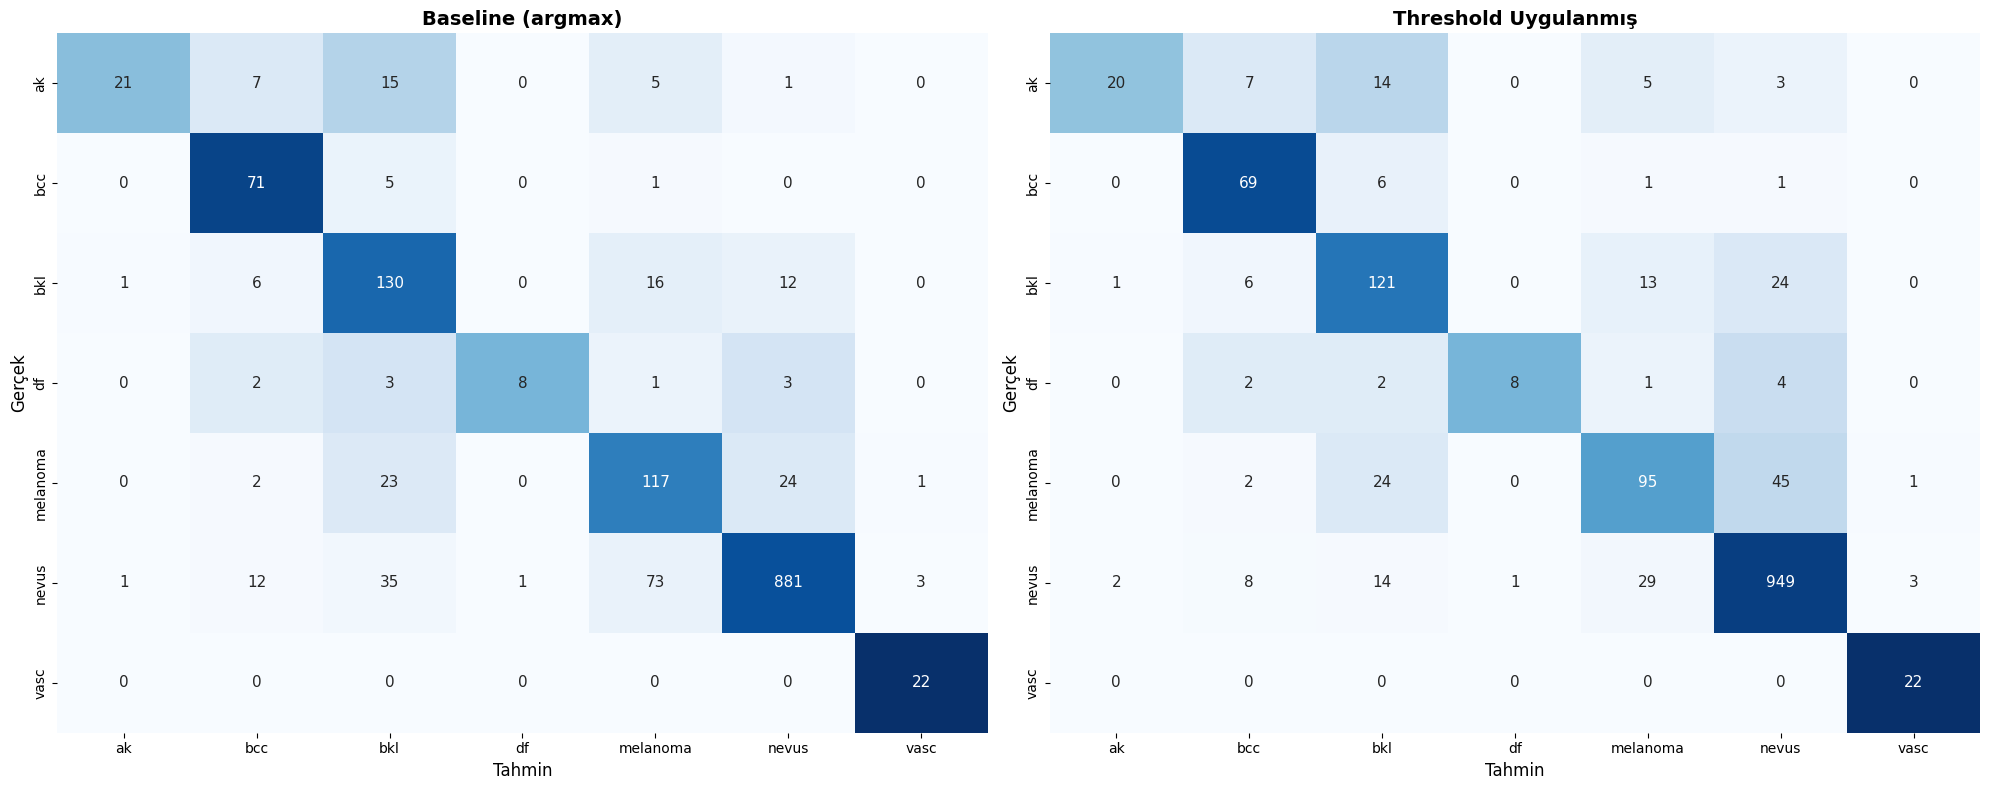

Confusion matrix kaydedildi ✅


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, preds, title in zip(
    axes,
    [test_preds_base, test_preds_thr],
    ["Baseline (argmax)", "Threshold Uygulanmış"]
):
    cm = confusion_matrix(test_labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt="d",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap="Blues", ax=ax, cbar=False,
                annot_kws={"size": 11})
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Tahmin", fontsize=12)
    ax.set_ylabel("Gerçek", fontsize=12)

plt.tight_layout()
plt.savefig(f"{BASE}/models_v3/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix kaydedildi ✅")

## 11. TTA — Test Time Augmentation (Opsiyonel, +%1-2 accuracy)

In [ ]:

tta_transforms = [
    A.Compose([A.Resize(224,224),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.HorizontalFlip(p=1.0),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.VerticalFlip(p=1.0),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(256,256), A.CenterCrop(224,224),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.Rotate(limit=15, p=1.0),
               A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
               ToTensorV2()]),
]

model.eval()
tta_probs_all = []
tta_labels_all = []

print("TTA başlıyor...")
for i in range(0, len(test_dataset), 1):
    row = test_dataset.df.iloc[i]
    img_path = row["image_path"]
    lbl = row["label_idx"]

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    probs_tta = []
    with torch.no_grad():
        for tfm in tta_transforms:
            t_img = tfm(image=img_rgb)["image"].unsqueeze(0).to(device)
            out = model(t_img)
            prob = torch.softmax(out, dim=1).cpu().numpy()[0]
            probs_tta.append(prob)

    mean_prob = np.mean(probs_tta, axis=0)
    tta_probs_all.append(mean_prob)
    tta_labels_all.append(lbl)

    if i % 500 == 0:
        print(f"  {i}/{len(test_dataset)}")

tta_probs_all  = np.array(tta_probs_all)
tta_labels_all = np.array(tta_labels_all)
tta_preds      = tta_probs_all.argmax(axis=1)

tta_acc = (tta_preds == tta_labels_all).mean()
tta_f1  = f1_score(tta_labels_all, tta_preds, average="macro", zero_division=0)
print(f"TTA Accuracy: {tta_acc:.4f}")
print(f"TTA Macro-F1: {tta_f1:.4f}")
print()
print(classification_report(tta_labels_all, tta_preds,
                             target_names=CLASS_NAMES, zero_division=0))

TTA başlıyor...
  0/1503
  500/1503
  1000/1503
  1500/1503
TTA Accuracy: 0.8530
TTA Macro-F1: 0.7772

              precision    recall  f1-score   support

          ak       0.85      0.59      0.70        49
         bcc       0.73      0.94      0.82        77
         bkl       0.66      0.79      0.72       165
          df       0.91      0.59      0.71        17
    melanoma       0.61      0.68      0.64       167
       nevus       0.95      0.90      0.93      1006
        vasc       0.85      1.00      0.92        22

    accuracy                           0.85      1503
   macro avg       0.79      0.78      0.78      1503
weighted avg       0.87      0.85      0.86      1503



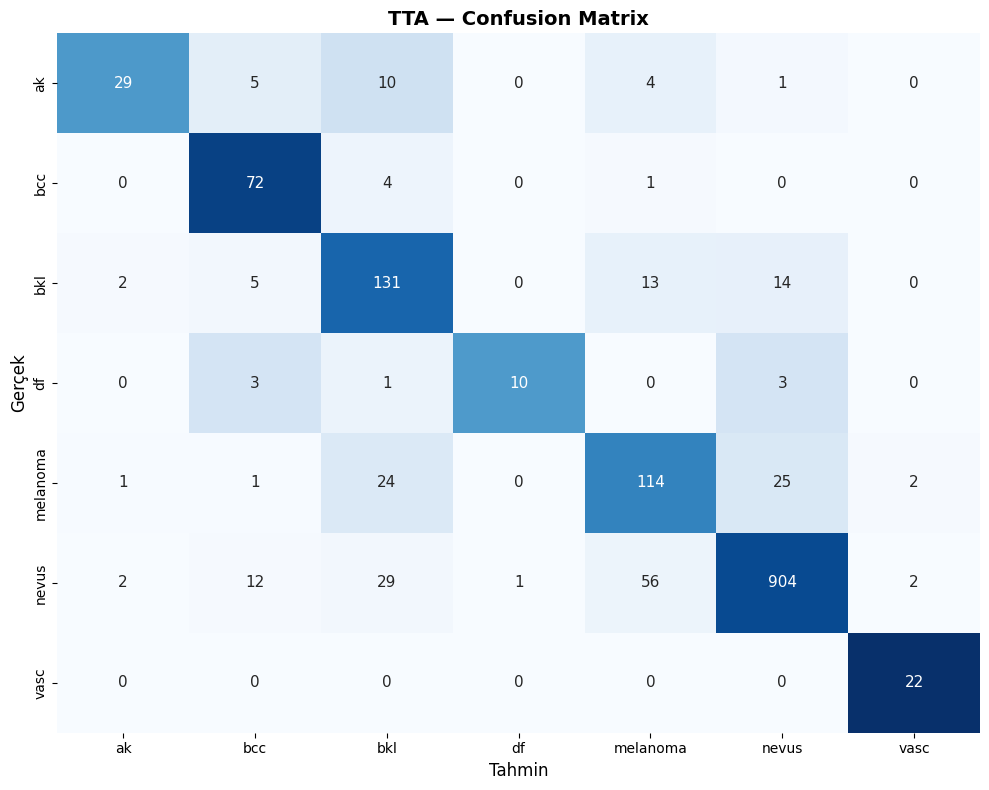

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(tta_labels_all, tta_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=cm, fmt="d",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap="Blues", ax=ax, cbar=False,
            annot_kws={"size": 11})
ax.set_title("TTA — Confusion Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Tahmin", fontsize=12)
ax.set_ylabel("Gerçek", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE}/models_v3/confusion_matrix_tta.png", dpi=150, bbox_inches="tight")
plt.show()